In [1]:
# Install packages (if not already installed in mehak env)
!pip install pandas numpy scikit-learn matplotlib tensorflow


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   -------- ------------------------------- 2.4/11.1 MB 13.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.8/11.1 MB 14.1 MB/s eta 0:00:01
   ------------------------------- -------- 8.7/11.1 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 13.9 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import mean_squared_error


In [7]:
df = pd.read_csv("Final_SCATS_with_LatLong.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8788 entries, 0 to 8787
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Site ID               8788 non-null   int64  
 1   Date                  8788 non-null   object 
 2   Interval              8788 non-null   object 
 3   Volume                8787 non-null   float64
 4   IntervalNum           8787 non-null   float64
 5   Time                  8787 non-null   object 
 6   Timestamp             8787 non-null   object 
 7   Location Description  8787 non-null   object 
 8   Site Type             8787 non-null   object 
 9   Directory             8787 non-null   object 
 10  Map reference         8787 non-null   object 
 11  Lat                   8787 non-null   float64
 12  Long                  8787 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 892.7+ KB


,Site ID,Date,Interval,Volume,IntervalNum,Time,Timestamp,Location Description,Site Type,Directory,Map reference,Lat,Long
0,970,1900-01-05,T1,12.0,1.0,0 days 00:00:00,1900-01-05 00:00:00,WARRIGAL/HIGH ST RD,INT,Melway,060G10,-37.86703,145.09159
1,970,1900-01-05,T2,12.0,2.0,0 days 00:15:00,1900-01-05 00:15:00,WARRIGAL/HIGH ST RD,INT,Melway,060G10,-37.86703,145.09159
2,970,1900-01-05,T3,7.0,3.0,0 days 00:30:00,1900-01-05 00:30:00,WARRIGAL/HIGH ST RD,INT,Melway,060G10,-37.86703,145.09159
3,970,1900-01-05,T4,4.0,4.0,0 days 00:45:00,1900-01-05 00:45:00,WARRIGAL/HIGH ST RD,INT,Melway,060G10,-37.86703,145.09159
4,970,1900-01-05,T5,2.0,5.0,0 days 01:00:00,1900-01-05 01:00:00,WARRIGAL/HIGH ST RD,INT,Melway,060G10,-37.86703,145.09159


In [9]:
# Filter for Site ID 970
site_df = df[df['Site ID'] == 970].copy()

# Convert Timestamp to datetime and sort it
site_df['Timestamp'] = pd.to_datetime(site_df['Timestamp'])
site_df = site_df.sort_values(by='Timestamp').reset_index(drop=True)

# Keep only relevant columns for GRU
gru_df = site_df[['Timestamp', 'Volume']].copy()

# Show sample
gru_df.head()


,Timestamp,Volume
0,1900-01-05 00:00:00,12.0
1,1900-01-05 00:15:00,12.0
2,1900-01-05 00:30:00,7.0
3,1900-01-05 00:45:00,4.0
4,1900-01-05 01:00:00,2.0


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the Volume column
gru_df['Volume_scaled'] = scaler.fit_transform(gru_df[['Volume']])

# Preview scaled values
gru_df.head()


,Timestamp,Volume,Volume_scaled
0,1900-01-05 00:00:00,12.0,0.025478
1,1900-01-05 00:15:00,12.0,0.025478
2,1900-01-05 00:30:00,7.0,0.014862
3,1900-01-05 00:45:00,4.0,0.008493
4,1900-01-05 01:00:00,2.0,0.004246


In [19]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Set the number of timesteps
window_size = 10

# Get the volume series as a numpy array
volume_series = gru_df['Volume_scaled'].values

# Create sequences
X, y = create_sequences(volume_series, window_size)

# Reshape input for GRU: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))
# 🔧 Remove rows where y is NaN (just in case)
valid_indices = ~np.isnan(y)
X = X[valid_indices]
y = y[valid_indices]

# Check again
print("After cleaning, any NaNs in y?", np.isnan(y).any())

# Show shapes
X.shape, y.shape


After cleaning, any NaNs in y? False


((8777, 10, 1), (8777,))

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Build the GRU model
model = Sequential()
model.add(GRU(units=64, return_sequences=False, input_shape=(X.shape[1], 1)))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train-test split (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Any NaNs in y_test?", np.isnan(y_test).any())
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Any NaNs in y_test? False
Epoch 1/20


C:\Users\mehak\anaconda3\envs\mehak\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0224 - val_loss: 0.0189
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0098 - val_loss: 0.0187
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0095 - val_loss: 0.0189
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0099 - val_loss: 0.0192
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0096 - val_loss: 0.0187
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0102 - val_loss: 0.0191
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0099 - val_loss: 0.0192
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0094 - val_loss: 0.0187
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0097 - val_loss: 0.0185
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0092 - val_loss: 0.0189
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0095 - val_loss: 0.0188
Epoch 12/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - 

In [23]:
# Predict on test set
y_pred = model.predict(X_test)

# Inverse transform predictions and true values
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Print first 5 predicted vs actual values
for i in range(5):
    print(f"Predicted: {y_pred_inverse[i][0]:.2f}, Actual: {y_test_inverse[i][0]:.2f}")


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Predicted: 293.00, Actual: 245.00
Predicted: 237.26, Actual: 329.00
Predicted: 274.65, Actual: 275.00
Predicted: 255.25, Actual: 371.00
Predicted: 294.88, Actual: 367.00


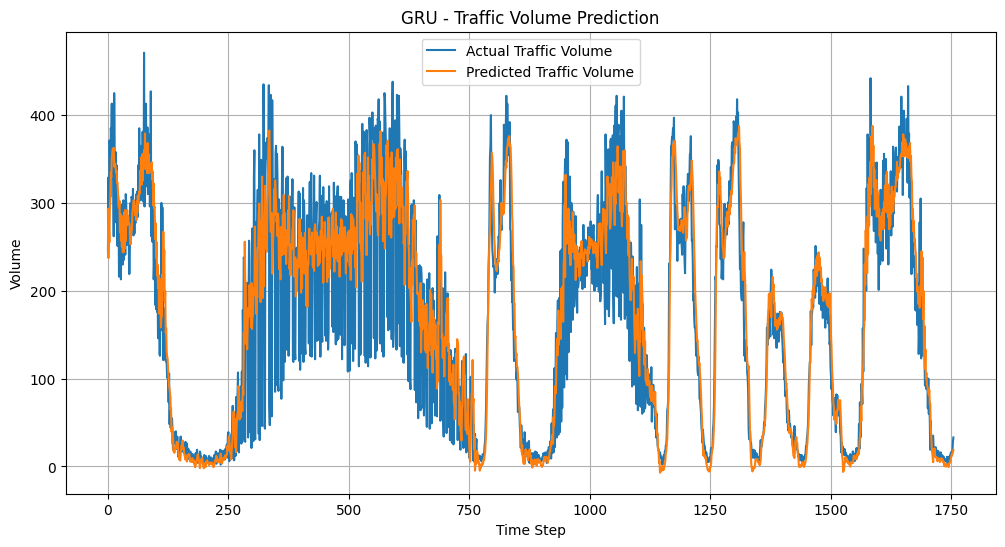

In [25]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inverse, label='Actual Traffic Volume')
plt.plot(y_pred_inverse, label='Predicted Traffic Volume')
plt.title("GRU - Traffic Volume Prediction")
plt.xlabel("Time Step")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


RMSE: 64.31
MAE: 42.73
